
════════════════════════════════════════════════════════════
  ФУНКЦИЯ : Розенброк
  Метод   : ДФП
════════════════════════════════════════════════════════════
  Стартовая точка       : [-1.5, 2.0]
  Найденный минимум     : [1.0, 1.0]
  Значение f в минимуме : 0.0
  Количество итераций   : 22
  Точек в релакс. посл. : 23
  ─────────────────────────────────────────────────────
  Проверка симметричности матриц:
  A^k = Δx Δxᵀ / (Δxᵀ Δg)      : ✓ симметрична всегда
  B^k = H Δg ΔgᵀH / (ΔgᵀH Δg)  : ✓ симметрична всегда
  H^(k+1) = H^k + A^k − B^k     : ✓ симметрична всегда
  ─────────────────────────────────────────────────────
  ΣA^k (теор. = H⁻¹ в минимуме):
    │     3.610237      8.837515 │
    │     8.837515     23.042629 │
  H⁻¹ в минимуме:
    │     0.499999      0.999999 │
    │     0.999999      2.004998 │
  ‖ΣA^k − H⁻¹‖ = 23.9814265
  ─────────────────────────────────────────────────────
  ΣB^k (теор. = I):
    │     4.109527      7.836125 │
    │     7.836125     22.034902 │
  

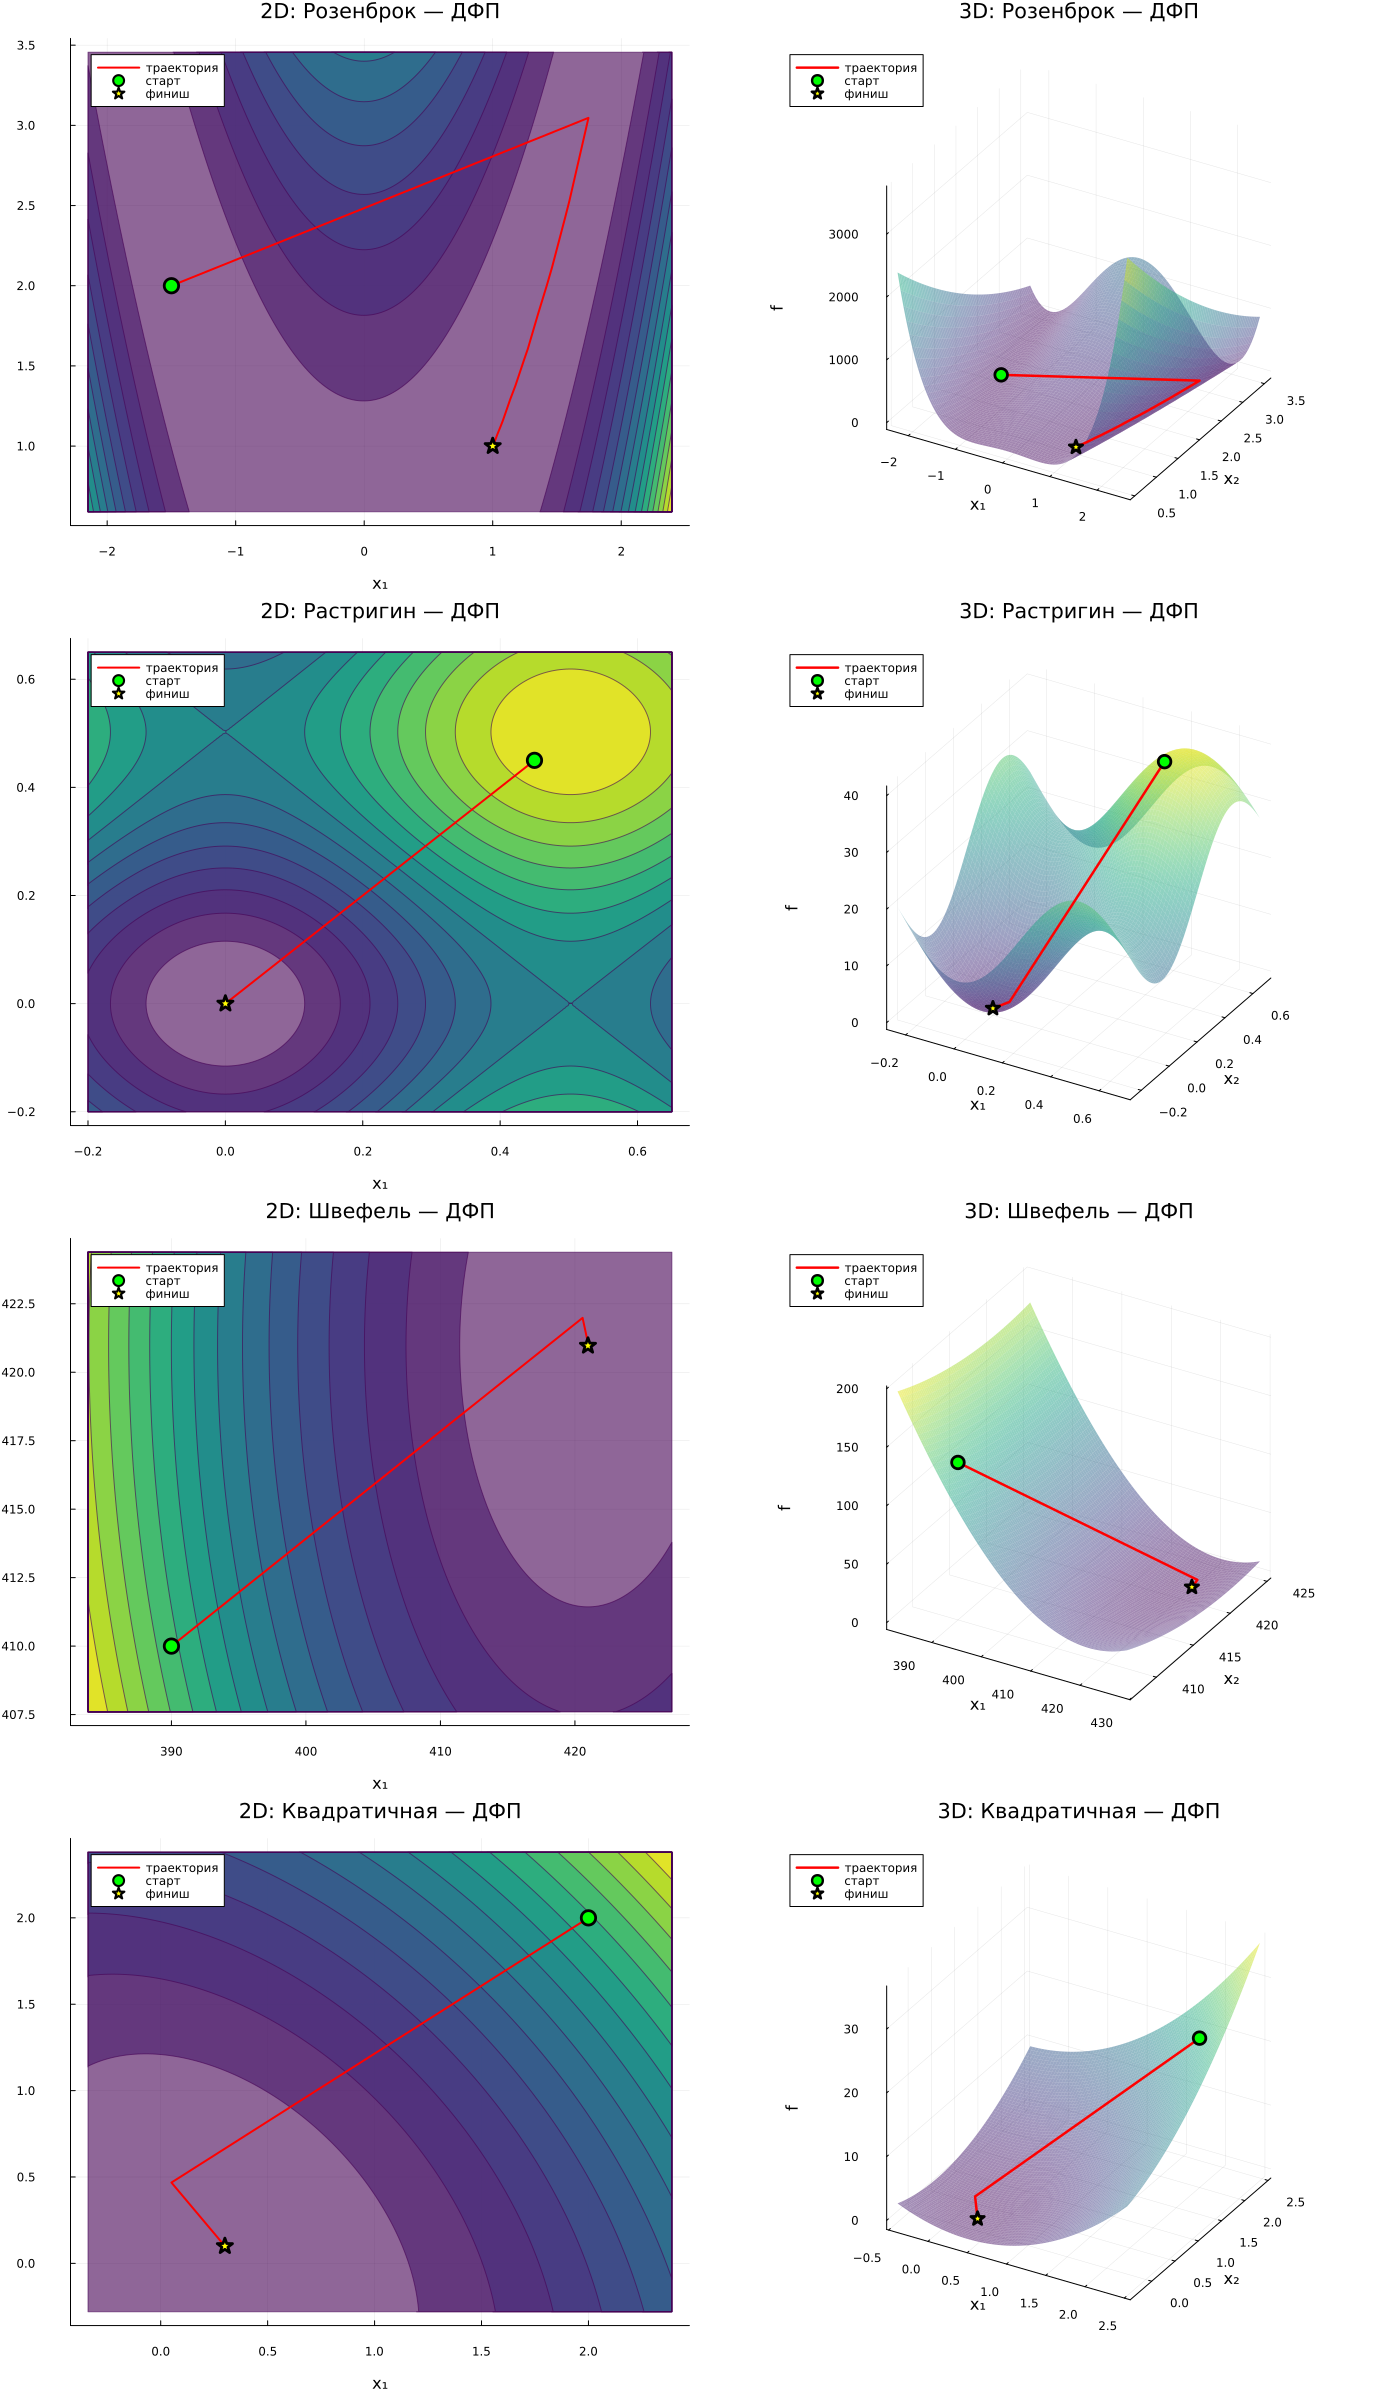

In [1]:
using LinearAlgebra
using Plots
gr()


f_rosen(x)  = (1.0 - x[1])^2 + 100.0 * (x[2] - x[1]^2)^2
f_rast(x)   = 20.0 + x[1]^2 - 10.0*cos(2π*x[1]) + x[2]^2 - 10.0*cos(2π*x[2])
f_schwef(x) = 418.9829*2 - (x[1]*sin(sqrt(abs(x[1]))) + x[2]*sin(sqrt(abs(x[2]))))
f_quad(x)   = 3.0*x[1]^2 + 2.0*x[1]*x[2] + 2.0*x[2]^2 - 2.0*x[1] - x[2]


function numgrad(f, x; h=1e-6)
    n  = length(x)
    xv = collect(Float64, x)
    g  = zeros(Float64, n)
    for i in 1:n
        ei   = zeros(Float64, n); ei[i] = 1.0
        g[i] = (f(xv .+ h .* ei) - f(xv .- h .* ei)) / (2h)
    end
    return g
end

function numhess(f, x; h=1e-4)
    n  = length(x)
    xv = collect(Float64, x)
    fx = f(xv)
    H  = zeros(Float64, n, n)
    for i in 1:n
        xp = copy(xv); xm = copy(xv)
        xp[i] += h;    xm[i] -= h
        H[i,i] = (f(xp) - 2fx + f(xm)) / h^2
    end
    for i in 1:n, j in (i+1):n
        xpp = copy(xv); xpm = copy(xv); xmp = copy(xv); xmm = copy(xv)
        xpp[i] += h; xpp[j] += h
        xpm[i] += h; xpm[j] -= h
        xmp[i] -= h; xmp[j] += h
        xmm[i] -= h; xmm[j] -= h
        v = (f(xpp) - f(xpm) - f(xmp) + f(xmm)) / (4h^2)
        H[i,j] = v; H[j,i] = v
    end
    return H
end

function golden_section(φ, a=0.0, b=1.0; tol=1e-6, max_iter=200)
    gr = (sqrt(5.0) + 1.0) / 2.0
    c  = b - (b - a) / gr
    d  = a + (b - a) / gr
    for _ in 1:max_iter
        abs(b - a) < tol && break
        if φ(c) < φ(d)
            b = d
        else
            a = c
        end
        c = b - (b - a) / gr
        d = a + (b - a) / gr
    end
    return (a + b) / 2.0
end

is_symmetric(M; tol=1e-10) = norm(M - M') < tol

function dfp(f, x0; epsilon1=1e-6, epsilon2=1e-6, max_iters=500, alpha_max=1.0)
    x    = collect(Float64, x0)
    n    = length(x)
    H    = Matrix{Float64}(I, n, n)
    grad = numgrad(f, x)
    hist = [copy(x)]

    sym_A_violations = 0
    sym_B_violations = 0
    sym_H_violations = 0

    sum_A = zeros(Float64, n, n)
    sum_B = zeros(Float64, n, n)

    for _ in 1:max_iters
        norm(grad) < epsilon2 && break

        p    = H * grad
        φ(α) = f(x .- α .* p)
        α    = golden_section(φ, 0.0, alpha_max)

        x_new    = x .- α .* p
        grad_new = numgrad(f, x_new)

        Δx = x_new .- x
        Δg = grad_new .- grad

        norm(Δx) < epsilon1 && break

        dxdg = dot(Δx, Δg)
        if abs(dxdg) > 1e-10 && dxdg > 0
            A   = (Δx * Δx') / dxdg
            z   = H * Δg
            zdg = dot(Δg, z)

            !is_symmetric(A) && (sym_A_violations += 1)
            sum_A += A

            if abs(zdg) > 1e-10
                B = (z * z') / zdg
                !is_symmetric(B) && (sym_B_violations += 1)
                sum_B += B
                H = H + A - B
            else
                H = H + A
            end
        end

        !is_symmetric(H) && (sym_H_violations += 1)

        if minimum(eigvals(Symmetric(H))) <= 0
            H = Matrix{Float64}(I, n, n)
        end

        x    = x_new
        grad = grad_new
        push!(hist, copy(x))
    end

    return x, hist, sym_A_violations, sym_B_violations, sym_H_violations, sum_A, sum_B
end


using Printf

function fmt_matrix(M; digits=6)
    n = size(M, 1)
    rows = []
    for i in 1:n
        row = join([@sprintf("%12.6f", round(M[i,j]; digits=digits)) for j in 1:n], "  ")
        push!(rows, "    │ $row │")
    end
    return join(rows, "\n")
end

function symcheck(violations, label)
    status = violations == 0 ? "✓ симметрична всегда" : "✗ нарушений: $violations"
    println("  $label : $status")
end

function print_results(fname, x0, xmin, hist, f, vA, vB, vH, sum_A, sum_B; is_quadratic=false)
    xmin_exact = hist[end]
    H_exact    = inv(numhess(f, xmin_exact))
    err_A      = norm(sum_A - H_exact)
    err_B      = norm(sum_B - I)

    println()
    println("═"^60)
    println("  ФУНКЦИЯ : $fname")
    println("  Метод   : ДФП")
    println("═"^60)
    println("  Стартовая точка       : $(round.(x0,     digits=6))")
    println("  Найденный минимум     : $(round.(xmin,   digits=6))")
    println("  Значение f в минимуме : $(round(f(xmin), digits=10))")
    println("  Количество итераций   : $(length(hist) - 1)")
    println("  Точек в релакс. посл. : $(length(hist))")
    println("  ─────────────────────────────────────────────────────")
    println("  Проверка симметричности матриц:")
    symcheck(vA, "A^k = Δx Δxᵀ / (Δxᵀ Δg)     ")
    symcheck(vB, "B^k = H Δg ΔgᵀH / (ΔgᵀH Δg) ")
    symcheck(vH, "H^(k+1) = H^k + A^k − B^k    ")
    println("  ─────────────────────────────────────────────────────")
    println("  ΣA^k (теор. = H⁻¹ в минимуме):")
    println(fmt_matrix(sum_A))
    println("  H⁻¹ в минимуме:")
    println(fmt_matrix(H_exact))
    println("  ‖ΣA^k − H⁻¹‖ = $(round(err_A; digits=8))")
    println("  ─────────────────────────────────────────────────────")
    println("  ΣB^k (теор. = I):")
    println(fmt_matrix(sum_B))
    println("  ‖ΣB^k − I‖   = $(round(err_B; digits=8))")
    println("═"^60)
end


function get_xy(hist)
    [p[1] for p in hist], [p[2] for p in hist]
end

function hist_bounds(hist; pad=0.2)
    xs, ys = get_xy(hist)
    xmin, xmax = minimum(xs), maximum(xs)
    ymin, ymax = minimum(ys), maximum(ys)
    dx = max(xmax - xmin, 1.0)
    dy = max(ymax - ymin, 1.0)
    return xmin - pad*dx, xmax + pad*dx, ymin - pad*dy, ymax + pad*dy
end

function plot2d(f, hist, fname; gridN=200)
    xmin, xmax, ymin, ymax = hist_bounds(hist)
    xg = range(xmin, xmax; length=gridN)
    yg = range(ymin, ymax; length=gridN)
    Z  = [f([x, y]) for y in yg, x in xg]
    xs, ys = get_xy(hist)

    p = contourf(xg, yg, Z;
                 color=:viridis, alpha=0.6, colorbar=false,
                 xlabel="x₁", ylabel="x₂",
                 title="2D: $fname — ДФП")
    plot!(p,    xs,        ys;        lw=2, color=:red,    label="траектория")
    scatter!(p, [xs[1]],   [ys[1]];   ms=8, color=:lime,   label="старт",  markershape=:circle)
    scatter!(p, [xs[end]], [ys[end]]; ms=8, color=:yellow, label="финиш", markershape=:star5)
    return p
end

function plot3d(f, hist, fname; gridN=80)
    xmin, xmax, ymin, ymax = hist_bounds(hist; pad=0.25)
    xg = range(xmin, xmax; length=gridN)
    yg = range(ymin, ymax; length=gridN)
    Z  = [f([x, y]) for y in yg, x in xg]
    xs, ys = get_xy(hist)
    fv     = [f([x, y]) for (x, y) in zip(xs, ys)]

    p = surface(xg, yg, Z;
                alpha=0.5, color=:viridis, colorbar=false,
                xlabel="x₁", ylabel="x₂", zlabel="f",
                title="3D: $fname — ДФП")
    plot!(p,    xs,        ys,        fv;        lw=2.5, color=:red,    label="траектория")
    scatter!(p, [xs[1]],   [ys[1]],   [fv[1]];   ms=7,  color=:lime,   label="старт",  markershape=:circle)
    scatter!(p, [xs[end]], [ys[end]], [fv[end]]; ms=7,  color=:yellow, label="финиш", markershape=:star5)
    return p
end


tests = [
    (f_rosen,  "Розенброк", [-1.5,   2.0  ], 1.0,  false),
    (f_rast,   "Растригин", [ 0.45,  0.45 ], 0.02, false),
    (f_schwef, "Швефель",   [390.0, 410.0 ], 5.0,  false),
    (f_quad,   "Квадратичная", [2.0,  2.0 ], 1.0,  true ),
]

all_plots = Plots.Plot[]

for (f, fname, x0, amax, is_quad) in tests
    xmin, hist, vA, vB, vH, sum_A, sum_B = dfp(f, x0; alpha_max=amax)
    print_results(fname, x0, xmin, hist, f, vA, vB, vH, sum_A, sum_B; is_quadratic=is_quad)
    push!(all_plots, plot2d(f, hist, fname))
    push!(all_plots, plot3d(f, hist, fname))
end

display(plot(all_plots...;
             layout     = (4, 2),
             size       = (1400, 2400)))